<a href="https://colab.research.google.com/github/halimAhtasham/DeepLearning/blob/main/08_Final_Model_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase 8: Final Model Selection**

Compare the tuned machine learning models using multiple evaluation
metrics and cross-validation stability.

Models:
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Standard deviation

The final test set remains untouched and will only be used in the
final evaluation phase.

In [1]:
import pandas as pd
import numpy as np
import os
import joblib

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PROJECT_PATH = "/content/drive/MyDrive/Machine Learning/Projects/Heart Disease Prediction"

DATASET_PATH = PROJECT_PATH + "/Dataset"
RESULT_PATH = PROJECT_PATH + "/Results"
MODEL_PATH = PROJECT_PATH + "/Models"

# **Load Dataset**

In [4]:
df = pd.read_csv(DATASET_PATH + "/heart.csv")

df_clean = df.drop_duplicates().copy()

print("Original dataset:", df.shape)
print("Cleaned dataset:", df_clean.shape)

Original dataset: (1025, 14)
Cleaned dataset: (302, 14)


# **Separate X and y**

In [5]:
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (241, 13)
Test: (61, 13)


# **Loading Tuned Model**

In [8]:
tuned_logistic = joblib.load(
    MODEL_PATH + "/tuned_logistic_regression.pkl"
)

tuned_knn = joblib.load(
    MODEL_PATH + "/tuned_knn.pkl"
)

tuned_tree = joblib.load(
    MODEL_PATH + "/tuned_decision_tree.pkl"
)

tuned_forest = joblib.load(
    MODEL_PATH + "/tuned_random_forest.pkl"
)

In [9]:
tuned_models = {
    "Logistic Regression": tuned_logistic,
    "KNN": tuned_knn,
    "Decision Tree": tuned_tree,
    "Random Forest": tuned_forest
}

# **Cross Validation Strategy**

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# **Define all Evaluation Metrics**

In [11]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# **Evaluate all Tuned Model**

In [12]:
final_cv_results = []

for name, model in tuned_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    final_cv_results.append({
        "Model": name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),

        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),

        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    })

In [13]:
final_cv_df = pd.DataFrame(final_cv_results)
final_cv_df.round(4)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.8379,0.0861,0.8284,0.0907,0.9006,0.0673,0.8600,0.0683,0.9135,0.0360
1,KNN,0.8545,0.0515,0.8328,0.0691,0.9308,0.0615,0.8753,0.0380,0.9254,0.0269
2,Decision Tree,0.8090,0.0312,0.8440,0.0775,0.8162,0.0930,0.8217,0.0322,0.8766,0.0361
3,Random Forest,0.8588,0.0612,0.8479,0.0661,0.9083,0.0626,0.8752,0.0527,0.9093,0.0486


## **Sort by F1**

In [14]:
final_cv_df.sort_values(
    "F1 Mean",
    ascending=False
).round(4)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
1,KNN,0.8545,0.0515,0.8328,0.0691,0.9308,0.0615,0.8753,0.0380,0.9254,0.0269
3,Random Forest,0.8588,0.0612,0.8479,0.0661,0.9083,0.0626,0.8752,0.0527,0.9093,0.0486
0,Logistic Regression,0.8379,0.0861,0.8284,0.0907,0.9006,0.0673,0.8600,0.0683,0.9135,0.0360
2,Decision Tree,0.8090,0.0312,0.8440,0.0775,0.8162,0.0930,0.8217,0.0322,0.8766,0.0361


## ***Metrics Details***

### **Accuracy**

In [15]:
final_cv_df[
    ["Model", "Accuracy Mean", "Accuracy Std"]
].sort_values(
    "Accuracy Mean",
    ascending=False
).round(4)

,Model,Accuracy Mean,Accuracy Std
3,Random Forest,0.8588,0.0612
1,KNN,0.8545,0.0515
0,Logistic Regression,0.8379,0.0861
2,Decision Tree,0.8090,0.0312


### **Precision**

In [16]:
final_cv_df[
    ["Model", "Precision Mean", "Precision Std"]
].sort_values(
    "Precision Mean",
    ascending=False
).round(4)

,Model,Precision Mean,Precision Std
3,Random Forest,0.8479,0.0661
2,Decision Tree,0.8440,0.0775
1,KNN,0.8328,0.0691
0,Logistic Regression,0.8284,0.0907


### **Recall**

In [17]:
final_cv_df[
    ["Model", "Recall Mean", "Recall Std"]
].sort_values(
    "Recall Mean",
    ascending=False
).round(4)

,Model,Recall Mean,Recall Std
1,KNN,0.9308,0.0615
3,Random Forest,0.9083,0.0626
0,Logistic Regression,0.9006,0.0673
2,Decision Tree,0.8162,0.0930


### **F1**

In [18]:
final_cv_df[
    ["Model", "F1 Mean", "F1 Std"]
].sort_values(
    "F1 Mean",
    ascending=False
).round(4)

,Model,F1 Mean,F1 Std
1,KNN,0.8753,0.0380
3,Random Forest,0.8752,0.0527
0,Logistic Regression,0.8600,0.0683
2,Decision Tree,0.8217,0.0322


### **ROC-AUC**

In [19]:
final_cv_df[
    ["Model", "ROC-AUC Mean", "ROC-AUC Std"]
].sort_values(
    "ROC-AUC Mean",
    ascending=False
).round(4)

,Model,ROC-AUC Mean,ROC-AUC Std
1,KNN,0.9254,0.0269
0,Logistic Regression,0.9135,0.0360
3,Random Forest,0.9093,0.0486
2,Decision Tree,0.8766,0.0361


## ***Comparision Table***

In [20]:
selection_table = final_cv_df[
    [
        "Model",
        "Accuracy Mean",
        "Precision Mean",
        "Recall Mean",
        "F1 Mean",
        "ROC-AUC Mean"
    ]
].copy()

selection_table = selection_table.round(4)

selection_table

,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
0,Logistic Regression,0.8379,0.8284,0.9006,0.8600,0.9135
1,KNN,0.8545,0.8328,0.9308,0.8753,0.9254
2,Decision Tree,0.8090,0.8440,0.8162,0.8217,0.8766
3,Random Forest,0.8588,0.8479,0.9083,0.8752,0.9093


## ***Ranking System***

In [21]:
ranking_df = final_cv_df[
    [
        "Model",
        "Accuracy Mean",
        "Precision Mean",
        "Recall Mean",
        "F1 Mean",
        "ROC-AUC Mean"
    ]
].copy()

ranking_df["Accuracy Rank"] = (
    ranking_df["Accuracy Mean"]
    .rank(ascending=False, method="min")
)

ranking_df["Precision Rank"] = (
    ranking_df["Precision Mean"]
    .rank(ascending=False, method="min")
)

ranking_df["Recall Rank"] = (
    ranking_df["Recall Mean"]
    .rank(ascending=False, method="min")
)

ranking_df["F1 Rank"] = (
    ranking_df["F1 Mean"]
    .rank(ascending=False, method="min")
)

ranking_df["ROC-AUC Rank"] = (
    ranking_df["ROC-AUC Mean"]
    .rank(ascending=False, method="min")
)

In [22]:
ranking_df[
    [
        "Model",
        "Accuracy Rank",
        "Precision Rank",
        "Recall Rank",
        "F1 Rank",
        "ROC-AUC Rank"
    ]
]

,Model,Accuracy Rank,Precision Rank,Recall Rank,F1 Rank,ROC-AUC Rank
0,Logistic Regression,3.0,4.0,3.0,3.0,2.0
1,KNN,2.0,3.0,1.0,1.0,1.0
2,Decision Tree,4.0,2.0,4.0,4.0,4.0
3,Random Forest,1.0,1.0,2.0,2.0,3.0


# **Visualization**

## **F1 Comparision**

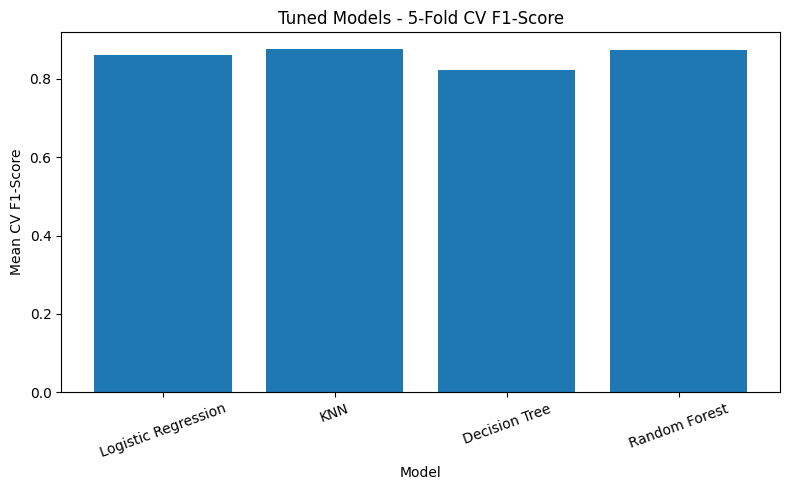

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    selection_table["Model"],
    selection_table["F1 Mean"]
)

plt.ylabel("Mean CV F1-Score")
plt.xlabel("Model")
plt.title("Tuned Models - 5-Fold CV F1-Score")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## **ROC-AUC Comparison**

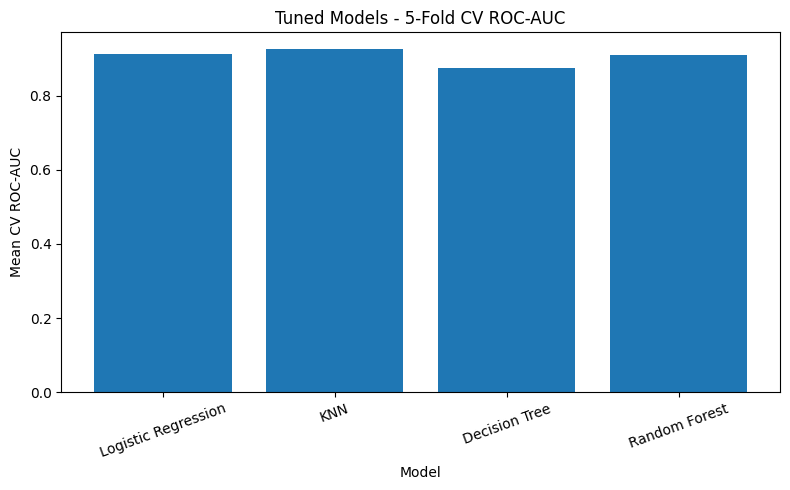

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    selection_table["Model"],
    selection_table["ROC-AUC Mean"]
)

plt.ylabel("Mean CV ROC-AUC")
plt.xlabel("Model")
plt.title("Tuned Models - 5-Fold CV ROC-AUC")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# **Save the Comparison**

In [25]:
final_cv_df.to_csv(
    RESULT_PATH + "/final_model_selection_cv_results.csv",
    index=False
)

selection_table.to_csv(
    RESULT_PATH + "/final_model_comparison.csv",
    index=False
)

# **Final MODEL**

In [26]:
final_model_name = "KNN"

final_model = tuned_models[final_model_name]

print("Selected Final Model:", final_model_name)

Selected Final Model: KNN


In [27]:
selection_summary = pd.DataFrame({
    "Selected Model": [final_model_name],
    "CV Accuracy": [0.8545],
    "CV Precision": [0.8328],
    "CV Recall": [0.9308],
    "CV F1": [0.8753],
    "CV ROC-AUC": [0.9254]
})

selection_summary

,Selected Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,KNN,0.8545,0.8328,0.9308,0.8753,0.9254


In [28]:
selection_summary.to_csv(
    RESULT_PATH + "/final_model_selection.csv",
    index=False
)

# Final Model Selection Conclusion

Based on stratified 5-fold cross-validation, the tuned KNN model was
selected as the final candidate model.

The tuned KNN achieved:

- Accuracy: 85.45%
- Precision: 83.28%
- Recall: 93.08%
- F1-score: 87.53%
- ROC-AUC: 92.54%

KNN achieved the highest recall, F1-score, and ROC-AUC among the evaluated
models. Its accuracy was also competitive with Random Forest, which achieved
85.88% accuracy and 87.52% F1-score.

Although Random Forest had slightly higher accuracy, the difference was
small, while KNN demonstrated stronger recall and ROC-AUC and lower F1-score
variability across folds.

Therefore, tuned KNN was selected as the final candidate model.

The final test set was not used during model selection and remains
untouched. It will be used only in the final evaluation phase.